In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_local = None
ref_annotation = None
ref_region = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""regulatory""","""abexp_max""","""#b5de2b""","""AbExp max""",1
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept (with their neutral filled values) instead of being dropped
keep_fillna = True

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),

        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        # (pl.col('pangolin_score') < 0.2), # Remove splice variants from the non-coding analysis
        
        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose regulatory region
        # (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),
    
        # Choose pLoF variants
        # (pl.col('loftee_hc') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # Gene-Body
selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir', '3utr'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_431971/1946513303.py:89: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_431971/1946513303.py:98: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


pangolin_score,region,esmscoremissense,absplice_dna_max,id,am_pathogenicity,score_pai3d,cadd_raw,gpn_score,absplice2_max,delta_score,verphylop
f32,str,f32,f32,str,f32,f32,f32,f32,f32,f32,f32
0.0,"""ENSG00000155657""",-4.66,0.001,"""chr2:178795028:T:C""",0.3975,0.0,2.389754,-7.45,0.000033,0.0,2.713
0.0,"""ENSG00000184999""",-7.895,0.003,"""chr11:63290536:A:C""",0.1285,0.541813,0.440197,-4.16,0.000201,0.0,-0.924
0.0,"""ENSG00000135956""",-6.354,0.001,"""chr2:96265270:C:G""",0.996,0.8291,4.87778,-11.34,0.000033,0.0,6.673
0.0,"""ENSG00000205189""",-3.546,0.001,"""chr8:80487528:A:G""",0.506,0.0,3.4702,-8.56,0.000033,0.0,3.797
0.02,"""ENSG00000143382""",-5.567,0.003,"""chr1:150557191:C:T""",0.0772,0.308568,1.016982,-2.91,0.002237,0.01,0.199
…,…,…,…,…,…,…,…,…,…,…,…
0.0,"""ENSG00000132693""",-7.537,0.003,"""chr1:159713719:C:T""",0.2634,0.533682,3.258595,-2.66,0.000428,0.0,1.331
0.04,"""ENSG00000174282""",-3.264,0.001,"""chr17:7462167:T:C""",0.0816,0.0,3.436205,-5.79,0.000034,0.0,1.028
0.02,"""ENSG00000049323""",-2.908,0.003,"""chr2:32948891:G:A""",0.3573,0.0,4.518946,-6.23,0.000473,0.0,8.042


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_431971/591762006.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr8:108268347:T:C""","""ENSG00000104408""","""esmscoremissense""",1
"""chr2:71276645:C:T""","""ENSG00000075292""","""esmscoremissense""",1
"""chr2:71276708:G:A""","""ENSG00000075292""","""esmscoremissense""",1
"""chr8:108268329:T:C""","""ENSG00000104408""","""esmscoremissense""",1
"""chr1:58473895:T:C""","""ENSG00000162600""","""esmscoremissense""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    .pipe(lambda df: df if keep_fillna else df.join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    ))

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation", "region"]).cast(pl.Float32)
    )
    .with_columns(
        annotation_score_dircor_quantile_desc = pl.col('annotation_score_dircor_rank_desc') / pl.col('annotation_score_dircor_rank_desc').max().over(["annotation", "region"])
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc,annotation_score_dircor_quantile_desc
str,str,str,f32,str,i8,f32,f32
"""chr2:233672716:A:G""","""ENSG00000241119""","""am_pathogenicity""",0.5152,"""missense""",1,93.0,0.317406
"""chr17:1478148:T:C""","""ENSG00000197879""","""am_pathogenicity""",0.8601,"""missense""",1,171.0,0.263077
"""chr9:69221242:G:C""","""ENSG00000119139""","""am_pathogenicity""",0.1009,"""missense""",1,438.0,0.631124
"""chr15:57282477:A:G""","""ENSG00000140262""","""am_pathogenicity""",0.0,"""missense""",1,387.0,1.0
"""chr8:80519311:G:A""","""ENSG00000205189""","""am_pathogenicity""",0.9129,"""missense""",1,41.0,0.090909
…,…,…,…,…,…,…,…
"""chr9:121046354:C:T""","""ENSG00000106804""","""am_pathogenicity""",0.0657,"""missense""",1,609.0,0.891654
"""chr2:178780041:C:T""","""ENSG00000155657""","""am_pathogenicity""",0.2818,"""missense""",1,814.0,0.04893
"""chr9:114168702:A:C""","""ENSG00000196739""","""am_pathogenicity""",0.0776,"""missense""",1,778.0,0.736045


In [8]:
anno['region'].value_counts(sort=True).filter(pl.col('count')>=500)

region,count
str,u64
"""ENSG00000155657""",16636
"""ENSG00000131018""",4196
"""ENSG00000008710""",3747
"""ENSG00000164199""",2885
"""ENSG00000143341""",2712
…,…
"""ENSG00000011426""",502
"""ENSG00000072786""",501
"""ENSG00000140829""",501


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


## Odds ratio computation

In [15]:
n_steps = 101

# zscore_threshold = 0.634546   #Obtained from LOFTEE_avg_effect_pheno.ipynb
zscore_threshold = 3
quant_threshold = stats.norm.cdf(zscore_threshold)
print(f"z-score: {zscore_threshold:.4f} --> Quantile threshold: {quant_threshold:.4f}")

# --- Within-gene quantile cutoffs ---
min_quantile_cutoff = 1e-3   # top 0.1% of variants within each gene
quantile_steps = np.geomspace(min_quantile_cutoff, 1.0, n_steps)

cutoffs_sorted = (
    pl.LazyFrame({"quantile_cutoff": quantile_steps})
    .with_columns(pl.col('quantile_cutoff').cast(pl.Float32))
    .sort('quantile_cutoff')
    .collect()
)

# --- Within-gene rank cutoffs (commented out) ---
# min_rank_cutoff = 1
# max_rank_cutoff = int(melted_anno['annotation_score_dircor_rank_desc'].max())
# rank_steps = np.unique(np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps).astype(int))
# cutoffs_sorted = (
#     pl.LazyFrame({"rank_cutoff": rank_steps})
#     .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
#     .sort('rank_cutoff')
#     .collect()
# )

print(f"Quantile range: {quantile_steps[0]:.5f} → {quantile_steps[-1]:.5f}")
cutoffs_sorted

z-score: 3.0000 --> Quantile threshold: 0.9987
Quantile range: 0.00100 → 1.00000


quantile_cutoff
f32
0.001
0.001072
0.001148
0.00123
0.001318
…
0.758578
0.812831
0.870964


In [16]:
# --- Pre-aggregate per-(region, annotation, quantile_cutoff) counts ---
# Variants are ranked within each gene. For each within-gene quantile cutoff,
# the OR is computed per gene and the mean + CI are taken across genes.

id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: compute is_extreme using z-score threshold
gp_base = (
    appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(-pl.col('mean_pheno_value'))
                .otherwise(pl.col('mean_pheno_value'))
            >= zscore_threshold
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

# --- Step 1: Pre-aggregate per (region, annotation, quantile_cutoff) 2x2 table counts ---
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
all_regions_df = pl.DataFrame({'region': all_regions})

annotations_list = sorted(melted_anno['annotation'].unique().to_list())
n_annotations = len(annotations_list)
n_cutoffs = cutoffs_sorted.shape[0]

# 4D array: (n_annotations, n_regions, n_cutoffs, 4)
# 4 = [n_dis_above, n_notdis_above, n_dis_below, n_notdis_below]
counts_4d = np.zeros((n_annotations, n_regions, n_cutoffs, 4), dtype=np.int64)

for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_quantile_desc'])
        # Rank version (commented out):
        # .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    # Group by (region, within-gene quantile), count extreme vs total
    region_rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by(['region', 'annotation_score_dircor_quantile_desc'])
        # Rank version (commented out):
        # .group_by(['region', 'annotation_score_dircor_rank_desc'])
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort(['region', 'annotation_score_dircor_quantile_desc'])
        # Rank version (commented out):
        # .sort(['region', 'annotation_score_dircor_rank_desc'])
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum().over('region'),
            cum_total = pl.col('n_total').cum_sum().over('region'),
        )
    )

    # Per-region totals
    region_totals = (
        region_rank_counts
        .group_by('region')
        .agg(
            total_extreme = pl.col('n_extreme').sum(),
            total_count = pl.col('n_total').sum(),
        )
    )

    # Cross join quantile cutoffs × ALL regions, then asof join by region
    per_region = (
        cutoffs_sorted
        .join(all_regions_df, how='cross')
        .sort(['region', 'quantile_cutoff'])
        # Rank version (commented out):
        # .sort(['region', 'rank_cutoff'])
        .join_asof(
            region_rank_counts.sort(['region', 'annotation_score_dircor_quantile_desc']),
            left_on='quantile_cutoff',
            right_on='annotation_score_dircor_quantile_desc',
            # Rank version (commented out):
            # left_on='rank_cutoff',
            # right_on='annotation_score_dircor_rank_desc',
            by='region',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .join(region_totals, on='region', how='left')
        .with_columns(
            total_extreme = pl.col('total_extreme').fill_null(0),
            total_count = pl.col('total_count').fill_null(0),
        )
        .with_columns(
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.col('total_extreme') - pl.col('cum_extreme'),
            n_notdis_below = (pl.col('total_count') - pl.col('total_extreme'))
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .sort(['region', 'quantile_cutoff'])
        # Rank version (commented out):
        # .sort(['region', 'rank_cutoff'])
    )

    counts_4d[a_idx, :, :, 0] = per_region['n_dis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 1] = per_region['n_notdis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 2] = per_region['n_dis_below'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 3] = per_region['n_notdis_below'].to_numpy().reshape(n_regions, n_cutoffs)

print(f"Pre-aggregated: {counts_4d.shape} = {n_annotations} annos × {n_regions} regions × {n_cutoffs} cutoffs × 4 counts")
print(f"Memory: {counts_4d.nbytes / 1e6:.1f} MB")

# --- Step 2: Per-gene odds ratios (n_annotations, n_regions, n_cutoffs) ---
with np.errstate(divide='ignore', invalid='ignore'):
    per_gene_or = (counts_4d[:, :, :, 0] / counts_4d[:, :, :, 1]) / \
                  (counts_4d[:, :, :, 2] / counts_4d[:, :, :, 3])
# Mask non-positive and non-finite values (genes with no carriers at this cutoff)
per_gene_or = np.where(np.isfinite(per_gene_or) & (per_gene_or > 0), per_gene_or, np.nan)

# --- Step 3: Mean OR and 95% CI across genes at each quantile cutoff ---
mean_or          = np.nanmean(per_gene_or, axis=1)           # (n_annotations, n_cutoffs)
ci_lower         = np.nanpercentile(per_gene_or, 2.5, axis=1)
ci_upper         = np.nanpercentile(per_gene_or, 97.5, axis=1)
n_genes_with_or  = np.sum(np.isfinite(per_gene_or), axis=1)  # for diagnostics

# Total pooled counts (for reference)
total_counts = counts_4d.sum(axis=1)  # (n_annotations, n_cutoffs, 4)

# --- Build output DataFrame ---
cutoff_values = cutoffs_sorted['quantile_cutoff'].to_numpy()
# Rank version (commented out):
# cutoff_values = cutoffs_sorted['rank_cutoff'].to_numpy()
anno_idx, cutoff_idx = np.meshgrid(np.arange(n_annotations), np.arange(n_cutoffs), indexing='ij')

or_df = (
    pl.DataFrame({
        'annotation': np.array(annotations_list)[anno_idx.ravel()],
        'quantile_cutoff': cutoff_values[cutoff_idx.ravel()],
        # Rank version (commented out):
        # 'rank_cutoff': cutoff_values[cutoff_idx.ravel()],
        'n_dis_above': total_counts[:, :, 0].ravel(),
        'n_notdis_above': total_counts[:, :, 1].ravel(),
        'n_dis_below': total_counts[:, :, 2].ravel(),
        'n_notdis_below': total_counts[:, :, 3].ravel(),
        'n_genes': n_genes_with_or.ravel(),
        'odds_ratio': mean_or.ravel(),
        'ci_lower': ci_lower.ravel(),
        'ci_upper': ci_upper.ravel(),
    })
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .sort('quantile_cutoff', descending=True)
    # Rank version (commented out):
    # .sort('rank_cutoff', descending=True)
)

print('unique quantile cutoffs:', or_df['quantile_cutoff'].n_unique())
or_df

Pre-aggregating: 100%|██████████| 10/10 [00:01<00:00,  6.10it/s]
/tmp/ipykernel_431971/19064468.py:131: RuntimeWarning: Mean of empty slice
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered


Pre-aggregated: (10, 670, 101, 4) = 10 annos × 670 regions × 101 cutoffs × 4 counts
Memory: 21.7 MB
unique quantile cutoffs: 100


annotation,quantile_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,n_genes,odds_ratio,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,i64,f64,f64,f64
"""absplice2_max""",0.933254,319,239722,80,99794,15,1.683752,0.07634,6.387433
"""absplice_dna_max""",0.933254,221,168540,178,170976,23,3.059409,0.109145,11.83551
"""am_pathogenicity""",0.933254,356,279977,43,59539,5,2.8879,0.064013,10.718817
"""cadd_raw""",0.933254,387,317042,12,22474,4,0.156623,0.069146,0.330776
"""delta_score""",0.933254,111,86096,288,253420,37,2.704685,0.355726,7.418745
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""",0.001,3,91,396,339425,2,683.6,415.32,951.88
"""absplice_dna_max""",0.001,2,84,397,339432,1,401.2,401.2,401.2
"""am_pathogenicity""",0.001,2,97,397,339419,1,122.961538,122.961538,122.961538


## Plotting

In [17]:
plt_df = (
    or_df
    .drop_nans()
    .filter(
        pl.col('odds_ratio').is_finite(),
        pl.col('odds_ratio') > 0,
        pl.col('ci_lower') > 0,
    )
    .with_columns(
        # log10 of within-gene quantile: -3 (top 0.1%) → 0 (all variants)
        log_quantile_cutoff = pl.col('quantile_cutoff').log10(),
        # Rank version (commented out):
        # log_rank_cutoff = pl.col('rank_cutoff').log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_quantile_cutoff')
    # Rank version (commented out):
    # .sort('log_rank_cutoff')
)

plt_df

annotation,quantile_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,n_genes,odds_ratio,ci_lower,ci_upper,log_quantile_cutoff,color,label,category
str,f32,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,str,str
"""absplice2_max""",0.001,3,91,396,339425,2,683.6,415.32,951.88,-3.0,"""#00838F""","""AbSplice2 (max)""","""splicing"""
"""absplice_dna_max""",0.001,2,84,397,339432,1,401.2,401.2,401.2,-3.0,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""am_pathogenicity""",0.001,2,97,397,339419,1,122.961538,122.961538,122.961538,-3.0,"""#FFCA28""","""AlphaMissense""","""missense"""
"""pangolin_score""",0.001,2,85,397,339431,1,966.0,966.0,966.0,-3.0,"""#2E7D32""","""Pangolin""","""splicing"""
"""score_pai3d""",0.001,1,60,398,339456,1,122.961538,122.961538,122.961538,-3.0,"""#D84315""","""PrimateAI-3D""","""missense"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",0.933254,377,316457,22,23059,9,0.210246,0.047313,0.809813,-0.03,"""#FB8C00""","""ESM1v""","""missense"""
"""gpn_score""",0.933254,389,317996,10,21520,6,0.154076,0.067982,0.322577,-0.03,"""pink""","""GPN-MSA""","""conservation"""
"""pangolin_score""",0.933254,161,121390,238,218126,35,1.95381,0.305992,6.32983,-0.03,"""#2E7D32""","""Pangolin""","""splicing"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


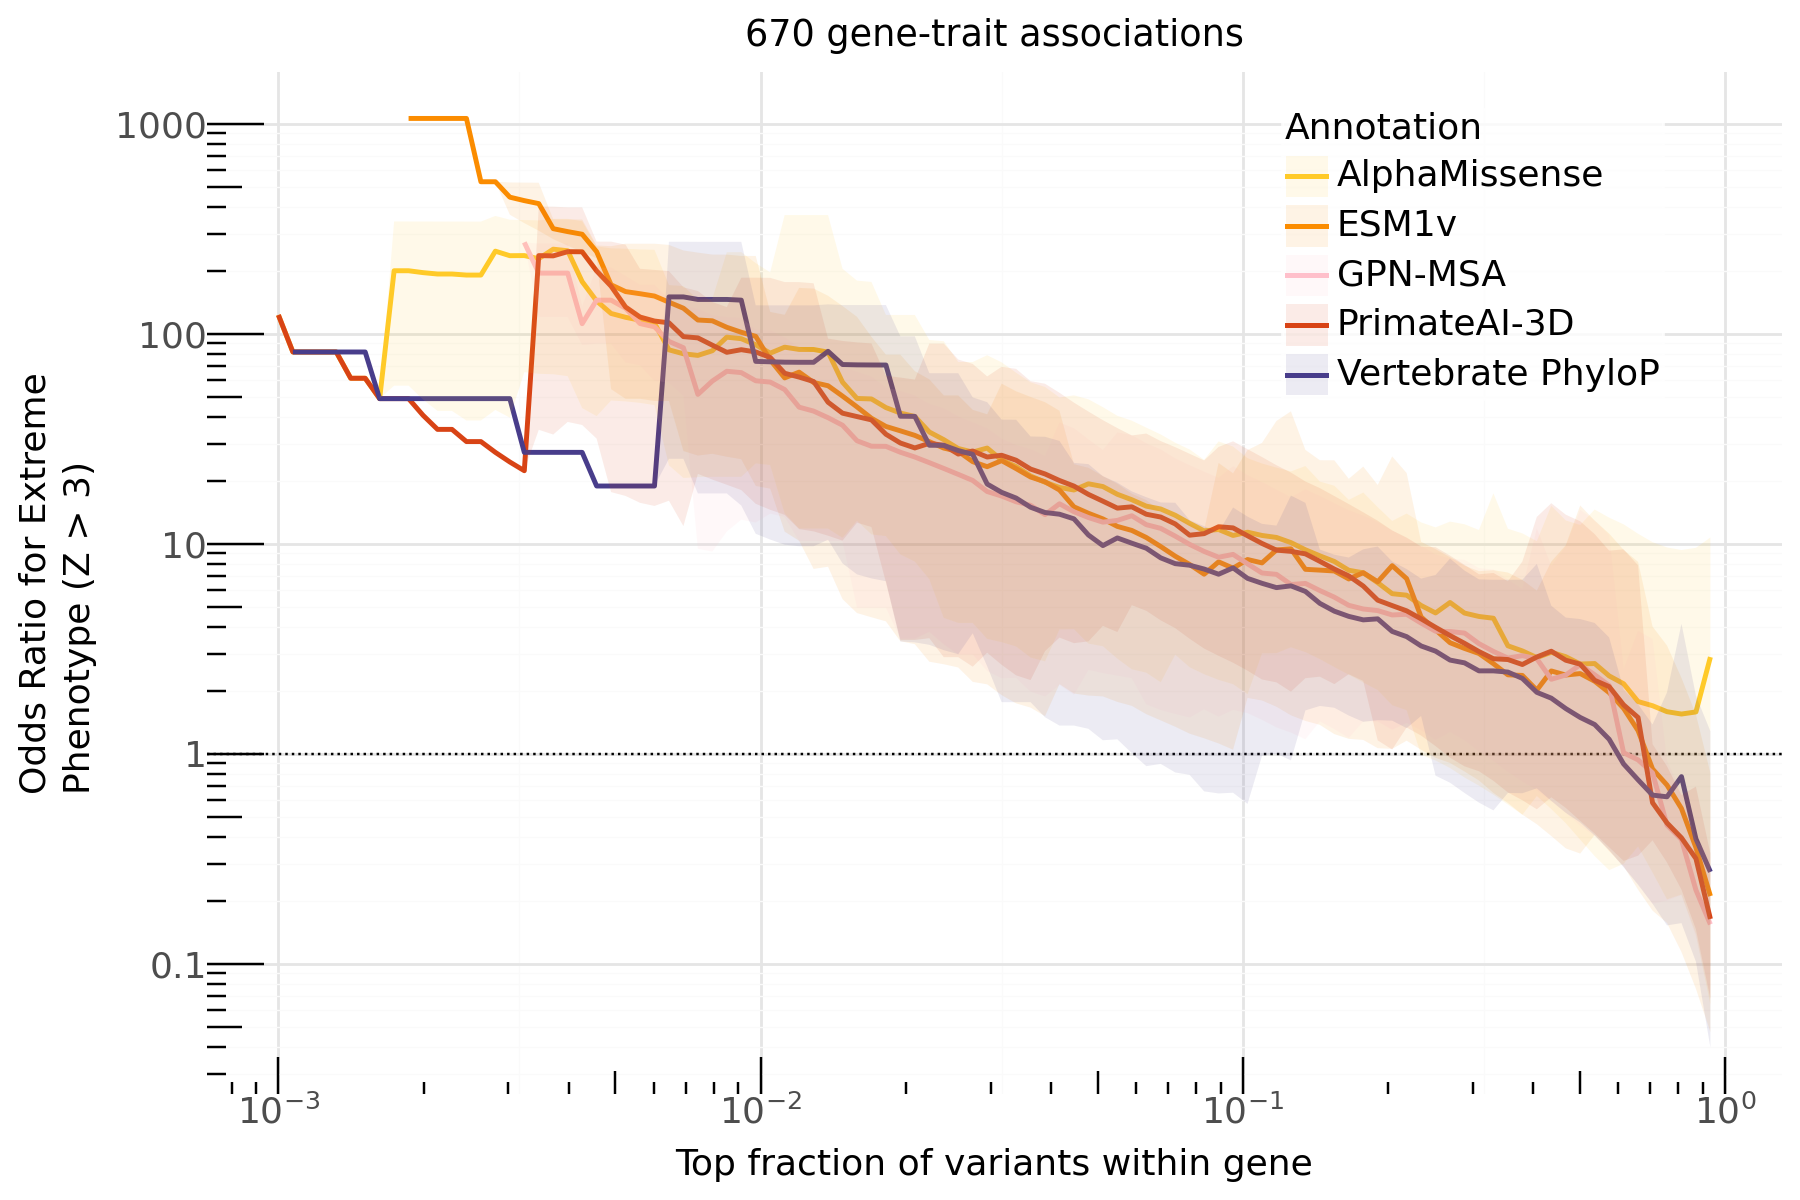

In [19]:
plot_df = (
    plt_df
    .filter(
        # Show from top 0.1% within gene (log=-3) up to all variants (log=0)
        (pl.col('log_quantile_cutoff') >= -3),
        # Rank version (commented out):
        # (pl.col('log_rank_cutoff') >= 0),

        (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'score_pai3d', 'gpn_score', 'verphylop']))
    )
)

# Generate breaks and labels for x-axis (quantile, log10 scale)
start_exp = int(np.log10(min_quantile_cutoff))  # e.g. -3
end_exp = 0  # log10(1.0) = 0
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]
# Rank version (commented out):
# start_exp = 0
# end_exp = int(np.log10(max_rank_cutoff)) + 1
# breaks_linear = np.arange(start_exp, end_exp + 1)
# labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round(zscore_threshold, 2)

(
    ggplot(
        plot_df,
        aes(x='log_quantile_cutoff', y='odds_ratio')
        # Rank version (commented out):
        # aes(x='log_rank_cutoff', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{gene_trait_df.shape[0]} gene-trait associations",
        y=f"Odds Ratio for Extreme\nPhenotype (Z > {pheno_label})",
        x=f"Top fraction of variants within gene",
        # Rank version (commented out):
        # x=f"Top N variants within gene (rank)",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.95),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)